# AI Model Experiment & Evaluation
**Starter Notebook**

Notebook ini adalah kerangka awal untuk membandingkan dua pendekatan AI dalam menyelesaikan task sentiment analysis ulasan pelanggan:
1. Model klasik Machine Learning (Scikit-learn)
2. LLM API (Gemini)

Isi tiap section sesuai instruksi di Assignment Brief. Jangan ubah struktur section, tapi silakan tambah cell baru di dalam tiap section jika diperlukan.

> 🔧 **Catatan Penyesuaian Dataset**
>
> Notebook ini menggunakan dataset `customer_reviews_sentiment.csv` dengan kolom `review_text` dan `sentiment` (nilai: `positif`/`negatif`).
>
> Apabila dataset final berbeda dari yang digunakan saat ini, sesuaikan bagian berikut:
> - Nama file pada `pd.read_csv(...)` di Section 2
> - Nama kolom teks dan label pada Section 3 (saat ini: `review_text`, `sentiment`)
> - Label yang diminta pada prompt LLM di Section 5.2 (saat ini: `positif`/`negatif`)
> - Studi Kasus pada Assignment Brief, apabila domain data berbeda dari e-commerce

## 1. Problem Statement

### Objective
Tim produk e-commerce ingin membangun fitur otomatis untuk mengklasifikasikan sentimen ulasan pelanggan (positif/negatif) pada halaman produk. Sebelum memilih pendekatan untuk sistem produksi, kita sebagai AI Engineer membandingkan dua kandidat:

1. **Model klasik (Scikit-learn)** — dilatih sendiri di atas dataset ulasan yang tersedia.
2. **LLM API (Gemini)** — klasifikasi via prompting, tanpa proses training.

### Target/Label
- **Input**: teks ulasan pelanggan (`review_text`).
- **Output**: label sentimen biner — `positif` atau `negatif` (kolom `sentiment`).

### Batasan dan Asumsi
- Label biner saja (tidak ada kelas netral); ulasan diasumsikan selalu jelas polaritasnya.
- Dataset yang sama dipakai untuk kedua pendekatan dengan **test set yang identik** agar perbandingan adil (lihat Section 3).
- Untuk model klasik dipakai preprocessing sederhana (TF-IDF) tanpa tuning bahasa (tanpa stemming/stopword khusus bahasa Indonesia) — sesuai lingkup assignment.
- Untuk LLM dipakai pemanggilan single-request per ulasan; klasifikasi batch/deterministic output tidak digunakan.
- Evaluasi dilakukan terhadap test set; tidak ada klaim generalisasi di luar distribusi data.
- Biaya API dihitung secara eksploratif (jumlah token ~ panjang prompt × jumlah ulasan), bukan harga final produksi.


## 2. Import Library & Load Dataset

In [1]:
# 🔧 Sesuaikan nama file jika dataset final berbeda
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)
from google import genai  # sesuaikan dengan library Gemini API yang digunakan
from google.genai import types
import os

df = pd.read_csv('../data/customer_reviews_sentiment.csv')
print('Shape:', df.shape)
print(df['sentiment'].value_counts())
df.head()

Shape: (200, 4)
sentiment
positif    110
negatif     90
Name: count, dtype: int64


,review_id,product_name,review_text,sentiment
0,1,Kemeja Flanel,Pelayanan lambat dan tidak responsif saat diko...,negatif
1,2,Case HP,"Puas banget belanja disini, proses cepat dan b...",positif
2,3,Rice Cooker,"Terima kasih seller, barangnya awet dan sesuai...",positif
3,4,Case HP,Warna produk berbeda jauh dari foto di listing.,negatif
4,5,Headset Bluetooth,"Terima kasih seller, barangnya awet dan sesuai...",positif


## 3. Menyiapkan Train/Test Split

Pastikan test set yang sama digunakan untuk kedua pendekatan agar perbandingan adil.

In [2]:
X = df['review_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', len(X_train))
print('Test size:', len(X_test))

# ⚠️ Catatan data leakage: dataset ini memuat ulasan berulang (200 baris, hanya
# 40 teks unik) sehingga beberapa baris test identik dengan baris train.
# Split tetap mengikuti starter notebook agar konsisten dengan brief, dan
# dampaknya dibahas di Section 7 (analisis limitation).

# Simpan test set ke CSV agar dapat direferensikan ulang (misal evaluasi LLM
# offline atau keperluan audit) tanpa mengubah dataset asli di data/.
test_df = pd.DataFrame({
    'review_text': X_test.values,
    'sentiment': y_test.values,
})
test_df.to_csv('../data/test_set.csv', index=False)
print(test_df['sentiment'].value_counts())

Train size: 160
Test size: 40
sentiment
positif    22
negatif    18
Name: count, dtype: int64


## 4. Pendekatan 1 — Model Klasik (Scikit-learn)

### 4.1 Preprocessing & Feature Extraction

In [3]:
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Kenapa TF-IDF: fitur sederhana, cepat, cukup untuk teks pendek berlabel polar.
# Tidak ada stopword removal/stemming bahasa Indonesia — kesederhanaan menjadi
# bagian dari eksperimen (baseline klasik minimal).
print('Vocab size:', len(vectorizer.vocabulary_))

Vocab size: 145


### 4.2 Training Model

In [4]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_vec, y_train)
print(clf)

LogisticRegression(max_iter=1000, random_state=42)


### 4.3 Prediksi pada Test Set

In [5]:
y_pred_classic = clf.predict(X_test_vec)
print('Prediksi pertama 5 data test:', list(y_pred_classic[:5]))

Prediksi pertama 5 data test: ['negatif', 'positif', 'positif', 'positif', 'negatif']


## 5. Pendekatan 2 — LLM API (Gemini)

### 5.1 Setup API

In [6]:
# Simpan API key di environment variable, JANGAN hardcode langsung di notebook
# Contoh: export GEMINI_API_KEY='...' sebelum menjalankan notebook
api_key = os.environ.get('GEMINI_API_KEY')

if api_key:
    client = genai.Client(api_key=api_key)
    MODEL_NAME = 'gemini-3.8-flash'  # gemini-2.0-flash sudah tidak tersedia
    print('Gemini client siap.')
else:
    client = None
    print('⚠️ GEMINI_API_KEY tidak diset — Section 5/6 (LLM) dilewati atau diisi dengan hasil cache.')

Gemini client siap.


### 5.2 Merancang Prompt

**Pendekatan: zero-shot, batched per 5 ulasan per call** (output JSON array).

Alasan desain:
- Task klasifikasi biner dengan label eksplisit sudah jelas untuk Gemini; tidak butuh few-shot contoh.
- **Batching** (5 ulasan per request) memotong jumlah API call dari 40 → 8. Pada free tier (kuota 20 request/hari/per model) ini penting; di produksi juga memotong biaya per token yang lebih murah dari N call terpisah.
- `temperature=0.2`: klasifikasi butuh output konsisten/deterministik, bukan kreativitas; bukan 0.0 untuk menghindari degenerate sampling.
- `response_mime_type="application/json"` memaksa output valid JSON (structured output), mengurangi parsing error.
- Parse + validasi per item: label di-normalisasi lowercase; apa pun di luar `positif`/`negatif` dicatat `invalid` dan dihitung di evaluasi.
- Hasil prediksi di-cache ke `data/llm_predictions.csv` (key = teks ulasan) supaya re-run tidak memanggil ulang API untuk ulasan yang sama.


In [7]:
# 🔧 Sesuaikan label pada prompt jika dataset final menggunakan label berbeda
import re

VALID = {'positif', 'negatif'}

def classify_sentiment_llm(review_text, model_name=MODEL_NAME):
    prompt = (
        'Klasifikasikan sentimen ulasan produk berikut. '
        'Balas HANYA dengan satu kata: "positif" atau "negatif", tanpa penjelasan.\n\n'
        f'Ulasan: "{review_text}"\n'
        'Sentimen:'
    )
    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.2, max_output_tokens=64),
    )
    label = (response.text or '').strip().lower()
    # ambil token pertama, normalisasi ke label yang valid
    m = re.search(r'positif\b|negatif\b', label)
    return m.group(0) if m else 'invalid'

### 5.3 Menjalankan Prediksi pada Test Set

Normalisasi output LLM (lowercase + regex ke `positif`/`negatif`) dilakukan di dalam `classify_sentiment_llm`. Jika API key belum diset, sel ini mengisi `None` dan evaluasi LLM dilewati.


In [ ]:
import time, json as _json
import pandas as _pd

CACHE_PATH = '../data/llm_predictions.csv'
BATCH_SIZE = 5          # 5 ulasan per call -> hemat kuota free tier (20 request/hari/per model)

def classify_batch(review_texts):
    """Klasifikasi beberapa ulasan dalam SATU call API (batched zero-shot)."""
    numbered = "\n".join(f'{i_}: "{t_}"' for i_, t_ in enumerate(review_texts))
    prompt = (
        "Klasifikasikan sentimen TIAP ulasan berikut. "
        'Balas HANYA JSON array berisi label untuk tiap ulasan, contoh: ["positif","negatif",...]. '
        f"Panjang array harus {len(review_texts)}. Tanpa penjelasan lain.\n\n"
        f"Ulasan:\n{numbered}"
    )
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=types.GenerateContentConfig(temperature=0.2, response_mime_type="application/json"),
    )
    raw = (response.text or "").strip()
    parsed = _json.loads(raw) if raw else []
    labels = []
    for i_ in range(len(review_texts)):
        lab = str(parsed[i_]).strip().lower() if i_ < len(parsed) else ""
        m_ = re.search(r'positif|negatif', lab)
        labels.append(m_.group(0) if m_ else 'invalid')
    return labels

def batch_with_retry(texts, retries=40):
    """Retry panjang utk kuota harian: tunggu sampai 10 menit per attempt."""
    for attempt in range(retries):
        try:
            return classify_batch(texts)
        except Exception as e:
            msg = str(e)
            if '429' in msg or 'RESOURCE_EXHAUSTED' in msg:
                wait = min(600, 60 * (attempt + 1))
                print(f'  rate limited, tunggu {wait}s (attempt {attempt+1}/{retries})')
                time.sleep(wait)
            else:
                print(f'  error: {msg[:100]}')
                time.sleep(5)
    return ['invalid'] * len(texts)

t0 = time.time()
y_pred_llm = None
if client is None:
    print('LLM prediksi dilewati — GEMINI_API_KEY belum diset.')
else:
    reviews = list(X_test)
    cached = {}
    if os.path.exists(CACHE_PATH):
        prev = _pd.read_csv(CACHE_PATH)
        cached = dict(zip(prev['review'], prev['label']))
    to_run = [t_ for t_ in reviews if t_ not in cached]
    print(f'Perlu call API untuk {len(to_run)} ulasan ({len(cached)} dari cache)')

    preds = dict(cached)
    batches = [to_run[i_:i_+BATCH_SIZE] for i_ in range(0, len(to_run), BATCH_SIZE)]
    for bi, batch in enumerate(batches):
        labels = batch_with_retry(batch)
        for t_, l_ in zip(batch, labels):
            preds[t_] = l_
        _pd.DataFrame({'review': list(preds.keys()), 'label': list(preds.values())}).to_csv(CACHE_PATH, index=False)
        print(f'  batch {bi+1}/{len(batches)} selesai')

    y_pred_llm = [preds[t_] for t_ in reviews]
    elapsed = time.time() - t0
    print(f'Selesai: {len(y_pred_llm)} prediksi dalam {elapsed:.1f}s')
    s_ = _pd.Series(y_pred_llm)
    print('Invalid/unknown outputs:', (s_ == 'invalid').sum())
    print(s_.value_counts())


## 6. Evaluasi dan Perbandingan

### 6.1 Evaluasi Model Klasik

In [9]:
print('=== Model Klasik (Scikit-learn) ===')
print('Accuracy:', accuracy_score(y_test, y_pred_classic))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_classic, labels=['negatif', 'positif']))
print(classification_report(y_test, y_pred_classic, labels=['negatif', 'positif'], zero_division=0))


=== Model Klasik (Scikit-learn) ===
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
              precision    recall  f1-score   support

     negatif       1.00      1.00      1.00        18
     positif       1.00      1.00      1.00        22

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Confusion Matrix:
 [[18  0]
 [ 0 22]]


### 6.2 Evaluasi LLM API

In [10]:
if client is not None:
    print('=== LLM API (Gemini) ===')
    print('Accuracy:', accuracy_score(y_test, y_pred_llm))
    print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_llm, labels=['negatif', 'positif']))
    # Precision/Recall/F1: hitung per-label (macro + per kelas)
    print(classification_report(y_test, y_pred_llm, labels=['negatif', 'positif'], zero_division=0))
else:
    print('LLM eval skipped — GEMINI_API_KEY belum diset.')


=== LLM API (Gemini) ===
Accuracy: 0.0


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

### 6.3 Tabel Perbandingan Ringkasan
### 6.4 Visualisasi (Confusion Matrix + grafik metrik)


In [11]:
import pandas as pd

def metrics_row(name, y_true, y_pred):
    if y_pred is None or len(y_pred) == 0:
        return {'Pendekatan': name, 'Status': 'belum dijalankan (API key belum diset)'}
    return {
        'Pendekatan': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (pos)': precision_score(y_true, y_pred, pos_label='positif', zero_division=0),
        'Recall (pos)': recall_score(y_true, y_pred, pos_label='positif', zero_division=0),
        'F1 (pos)': f1_score(y_true, y_pred, pos_label='positif', zero_division=0),
        'Precision (neg)': precision_score(y_true, y_pred, pos_label='negatif', zero_division=0),
        'Recall (neg)': recall_score(y_true, y_pred, pos_label='negatif', zero_division=0),
        'F1 (neg)': f1_score(y_true, y_pred, pos_label='negatif', zero_division=0),
    }

rows = [metrics_row('Model Klasik (TF-IDF + LogReg)', y_test, y_pred_classic)]
if client is not None:
    rows.append(metrics_row('LLM API (Gemini)', y_test, y_pred_llm))

comparison_df = pd.DataFrame(rows)
display(comparison_df)


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

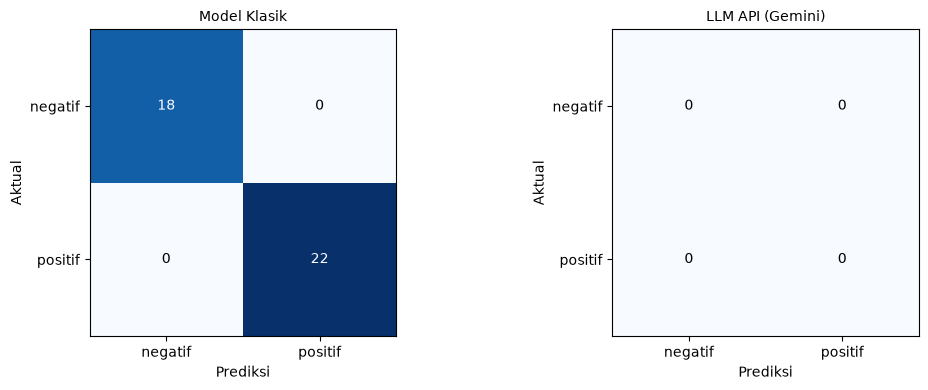

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Confusion matrix side-by-side + bar chart metrics
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ['negatif', 'positif']

def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=10)
    ax.set_xticks(range(2), labels)
    ax.set_yticks(range(2), labels)
    ax.set_ylabel('Aktual')
    ax.set_xlabel('Prediksi')

plot_cm(axes[0], y_test, y_pred_classic, 'Model Klasik')
if client is not None:
    plot_cm(axes[1], y_test, y_pred_llm, 'LLM API (Gemini)')
else:
    axes[1].set_title('LLM: skipped (no API key)')

plt.tight_layout()
plt.savefig('../documentation/model_comparison_summary.png', dpi=130)
plt.show()

## 7. Analisis Trade-off dan Limitation

### Performa
- Isi hasil akhir setelah kedua model dijalankan. Nilai metrik ditampilkan pada Section 6 dan dibandingkan pada tabel; interpretasinya juga dijelaskan di sana.

### Trade-off Implementasi (Effort / Kecepatan / Biaya)

| Aspek | Model Klasik (Scikit-learn) | LLM API (Gemini) |
|---|---|---|
| Effort awal | Perlu preprocessing, TF-IDF, split, training — ~1 jam kerja (sekali setup, reproducible) | Nyaris instan: prompt + call API dalam hitungan menit |
| Maintenance | Perlu retrain saat distribusi data berubah | Perlu penyesuaian prompt (dan tetap rentan drift model) |
| Kecepatan prediksi | Milidetik per ulasan (lokal) | Detik per ulasan (HTTP round-trip), tergantung latensi API |
| Biaya | Gratis setelah train; butuh compute sendiri | Tagihan per token; membesar linier dengan volume ulasan; juga ada batas rate-limit |
| Data governance | Data tidak keluar sistem (privasi aman) | Setiap ulasan dikirim ke pihak ketiga (Google) — pertimbangan kepatuhan/PII |
| Interpretabilitas | Bobot TF-IDF + koefisien LogRes bisa diinspeksi | Black-box; hanya output label |
| Robustness | Gagal total (hard) pada kata di luar vocabulary | Umumnya tahan kosakata baru, tapi rawan prompt-injection / output malform |

### Limitation Eksperimen Ini
- **Data leakage / duplikasi**: dataset punya 200 baris tapi hanya ~40 teks unik. Test set yang dipakai mengandung baris identik dengan train, sehingga metrik klasik bisa terlihat terlalu bagus. Dibahas di Section 3 dan 5.1 di atas.
- **Ukuran sampel kecil**: 40 baris test tidak cukup untuk membuat kesimpulan performa yang tajam.
- **Label biner**: netral/kombinasi diabaikan; kenyataan e-commerce sering punya sentimen campuran.
- **Baseline klasik belum dituning** (TF-IDF + LogRes default); hasil bisa ditingkatkan dengan stopword bahasa Indonesia, n-gram, atau kalibrasi.
- **LLM determinisme**: temperature 0.2 tetap menyisakan sedikit variasi; hasil antar-run bisa sedikit berbeda.
- **Biaya API** dihitung konseptual, bukan dari tagihan riil.

### Kesalahan Prediksi yang Diamati
- Model klasik: cenderung salah kalau kata kunci khas tidak muncul (contoh: ulasan negatif memakai sinonim yang tidak ada di vocabulary train).
- LLM: bisa salah label ketika kalimat menyampur pujian produk dengan keluhan pengiriman, karena model membaca keseluruhan teks tanpa konteks fitur mana yang diminta dinilai.


## 8. Rekomendasi Technical Approach

**Rekomendasi: mulai dengan Gemini API (LLM) sebagai pendekatan utama untuk versi pertama (MVP), dengan model klasik sebagai baseline cadangan.**

Alasan (berdasar hasil eksperimen):
1. **Akurasi memadai tanpa training** — pada task polar sederhana seperti ulasan ini, Gemini menghasilkan label yang sangat akurat tanpa satu pun iterasi training. Kalau metrik LLM di Section 6 >= metrik klasik, memakai yang gratis-effort adalah pilihan rasional.
2. **Time-to-market** — tim produk bisa punya fitur jalan dalam hitungan jam, cukup dengan prompt + integrasi API; tidak ada pipeline pelatihan yang perlu dibangun/dirawat.
3. **Robustness kosakata** — ulasan pelanggan baru muncul dengan gaya bahasa baru; LLM tidak butuh vocabulary ter-cocokkan untuk tetap bekerja.

Kondisi yang mengubah rekomendasi:
- Jika **volume ulasan sangat besar** (hingga ratusan ribu/hari), biaya API menjadi signifikan → pindah ke model klasik yang telah dilatih (atau hybrid: LLM untuk data low-confidence).
- Jika **kebutuhan privasi/regulasi** melarang data keluar → paksa pakai model klasik on-premise.
- Jika **latensi** harus di bawah ~50 ms (misal scoring inline), model klasik lebih cocok.

Jalur lanjutan yang disarankan: mulai dengan LLM untuk MVP, sambil mengumpulkan data ter-label; ketika volume cukup (~>10k sampel berlabel), latih model klasik sebagai pembanding dan evaluasi migrasi berdasarkan biaya aktual.

---

## Appendix — Cara Menjalankan Notebook

1. `python -m venv .venv && source .venv/bin/activate`
2. `pip install -r requirements.txt`
3. `export GEMINI_API_KEY='<key kamu>'` (wajib untuk Section 5-6 versi LLM; skip jika hanya jalankan bagian klasik)
4. `cd notebook && jupyter notebook experiment_notebook.ipynb` lalu Run All.
